In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys

import sympy

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy')

# in pycode folder, includes all the langevin-regression code implemented for 2d
import langevin_sindy as lg
import timecorr as tc
import fp_solvers as fps

# phase plane analysis code
import utils.pplane as pplane

# Euler-Maruyama for stochastic simulation of trajectories
from utils.stochastic_sim import stochastic_sim_EM

JEPA dataset info: 
- columns 0-255 are the latent features of the model
- T is the index of the timepoint (0 to 576, units 5 minutes)
- features over time for each of 54 image crops

Original endothelial cell dataset info (from `cellsmap/cellsmap/config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `jepa_feats_init.py`.

In [4]:
exp_var = np.load('../data/JEPA_ExpVar.npy')
pcs = np.load('../data/JEPA_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  2


In [5]:
X_t = np.load('../data/JEPA_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('../data/JEPA_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/JEPA_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

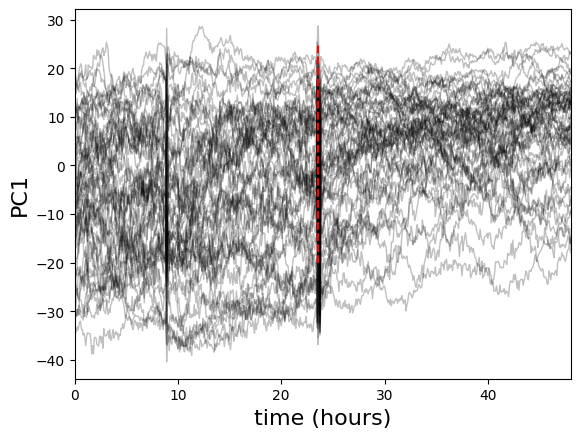

In [6]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

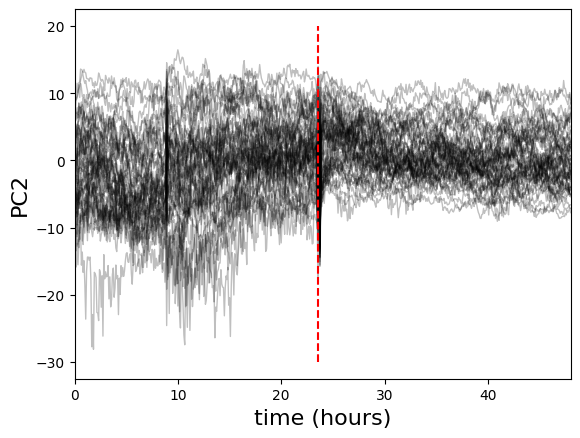

In [7]:
# plot 2nd PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC2')

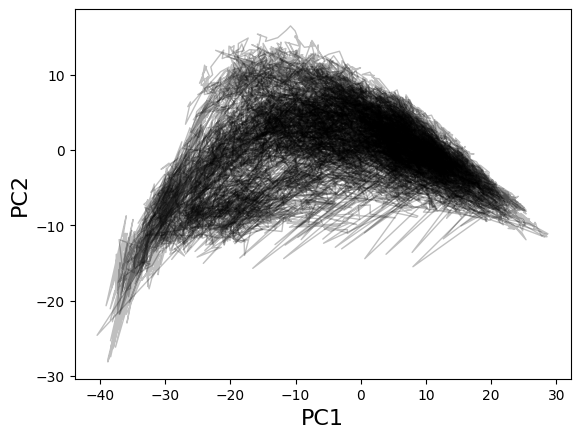

In [8]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

## Langevin regression (1D)

### High flow trajectories

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:45: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:46: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:47: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:48: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


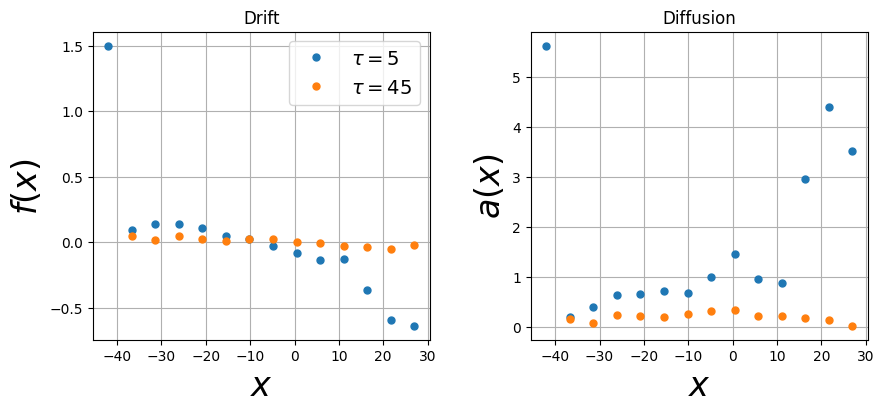

In [19]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 16 # Number of bins
bins = np.linspace(-50,35, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t_high[i,:,0] for i in range(num_loc)] # high flow data, pass as list into KM_avg
data_stationary = [X_t_high[i,-50:,0] for i in range(num_loc)] # for computing stationary density
dt=5

f_fine, a_fine, _,_ = lg.KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=9
f_coarse, a_coarse, _,_ = lg.KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

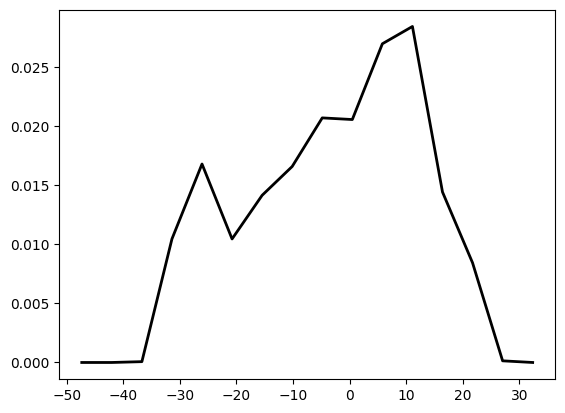

In [20]:
# PDF of states

p_hist = np.histogram(np.concatenate(data_stationary), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

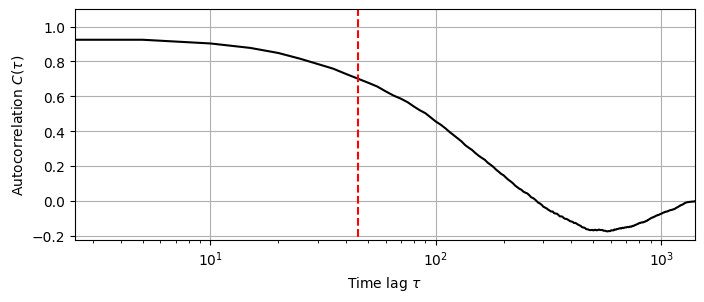

In [21]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + tc.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_23668/3768189026.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


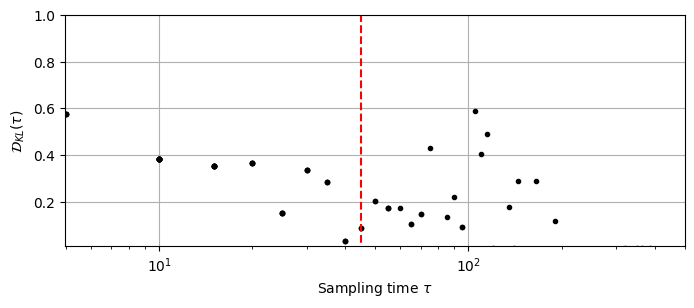

In [22]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx], delta, N=N) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [23]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = lg.KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

In [24]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_f = lib_f.T

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

lib_s = lib_s.T

In [25]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[mask], f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[mask], np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[ 5.08996665e-03 -2.58328422e-03 -5.99639735e-05  2.14941766e-06
  7.15989841e-08  7.56173687e-01 -8.17524777e-04 -4.77320765e-04
 -7.31309447e-06]


In [26]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data_stationary), bins, density=True)[0]

# Initialize adjoint solver
afp = fps.AdjFP(centers)

# Initialize forward steady-state solver
fp = fps.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: lg.AFP_opt(lg.cost, params)
Xi, V = lg.SSR_loop(opt_fun, params)

KeyboardInterrupt: 

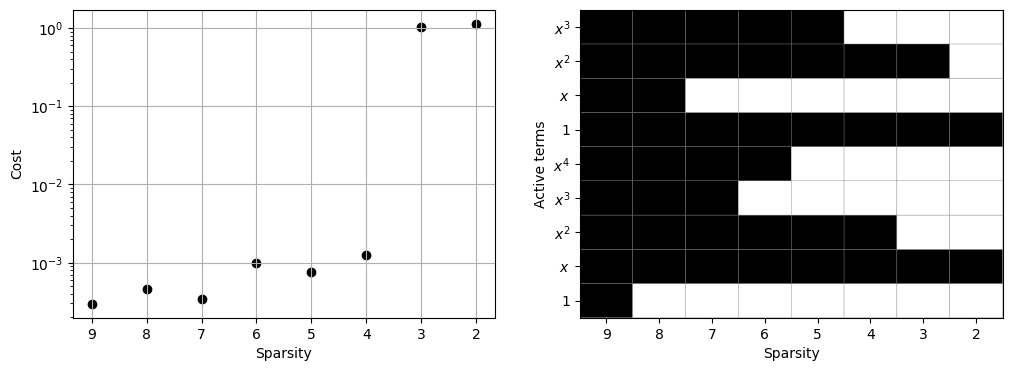

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 7
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy_high = sympy.lambdify(x, lg.sindy_model(Xi_f, f_expr))
a_sindy_high = sympy.lambdify(x, 0.5*lg.sindy_model(Xi_s, s_expr)**2)

Optimal sparsity:  7
Cost at optimal sparsity:  0.0003404561050906674
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['0', '-2.148E-03', '-4.832E-05', '1.815E-06', '5.730E-08']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['7.696E-01', '0', '-5.135E-04', '-8.313E-06']


In [ ]:
f_vals = f_sindy_high(centers)
a_vals = a_sindy_high(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

KL divergence (LINDy model): 0.10498


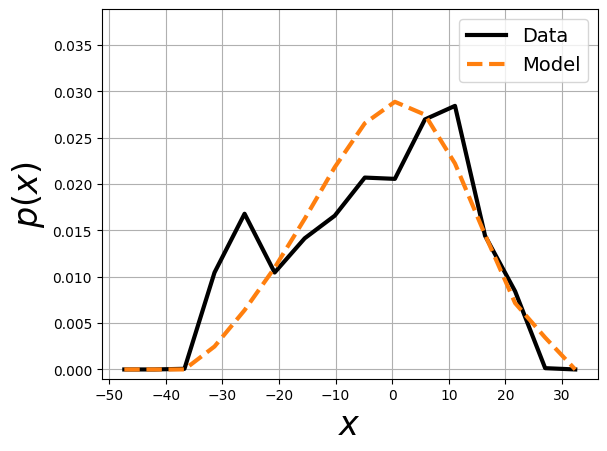

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
p_fit[p_fit < 0] = 0
p_fit[-1] = 0
p_fit = p_fit/np.trapz(p_fit, centers)
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
plt.ylim([-1e-3, np.max([p_hist.max()+0.01, p_fit.max()+0.01])])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()

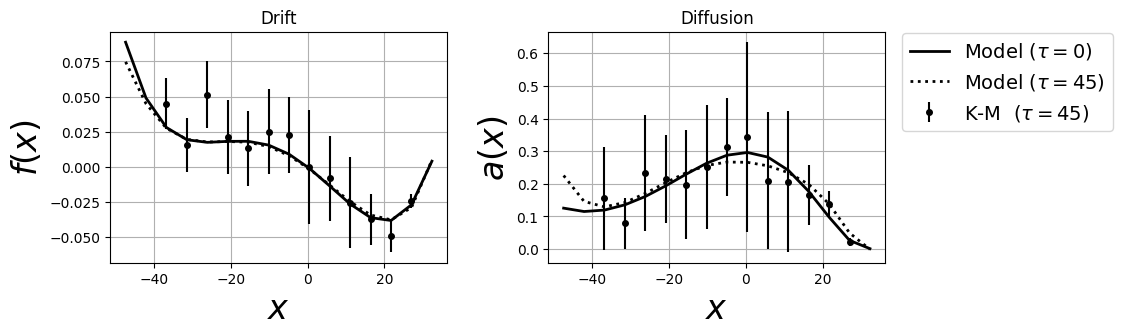

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
#plt.ylim([-1, 0.3])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
#plt.ylim([0, 1.25])

plt.subplots_adjust(wspace=0.3)
plt.show()

/tmp/ipykernel_927/67012155.py:11: RuntimeWarning: divide by zero encountered in log
  lnP = -np.log(p_fit)


Text(0.5, 0, '$x$')

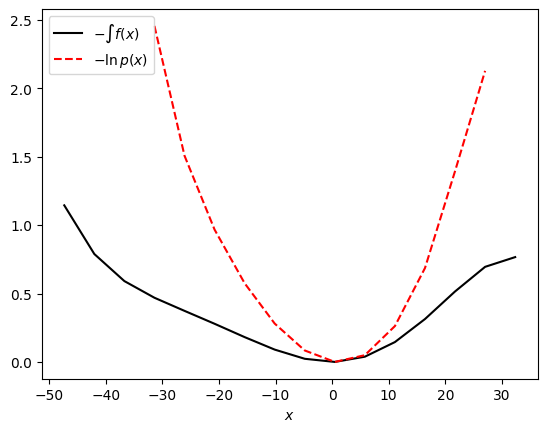

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy_high(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

lnP = -np.log(p_fit)
plt.plot(centers, Uvec-Uvec.min(), 'k-',label='$-\\int f(x)$')
plt.plot(centers, lnP-np.nanmin(lnP), 'r--',label='$-\\ln p(x)$')
plt.legend()
plt.xlabel('$x$')

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_high[inits_idx,0,0]

traj_model = stochastic_sim_EM(inits[:,None], f_sindy_high, lambda x: np.sqrt(2*a_sindy_high(x)), t_change, dt)[:,:,0]

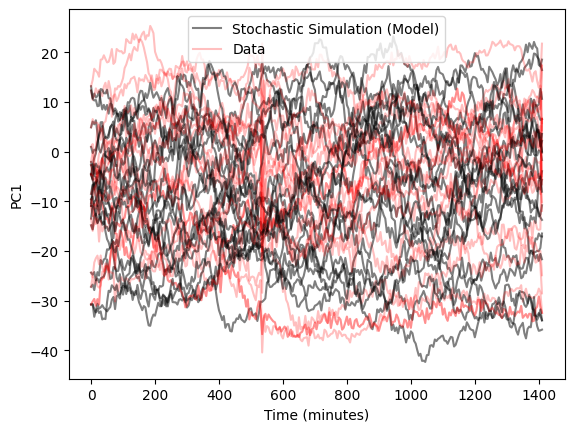

In [ ]:
for i in range(len(inits)):
    plt.plot(np.arange(t_change)*dt,traj_model[i,:],'k-',alpha=0.5)
    plt.plot(np.arange(t_change)*dt,X_t_high[inits_idx[i],:,0],'r-',alpha=0.25)

plt.xlabel('Time (minutes)')
plt.ylabel('PC1')
plt.legend(['Stochastic Simulation (Model)','Data'])

### Low flow trajectories

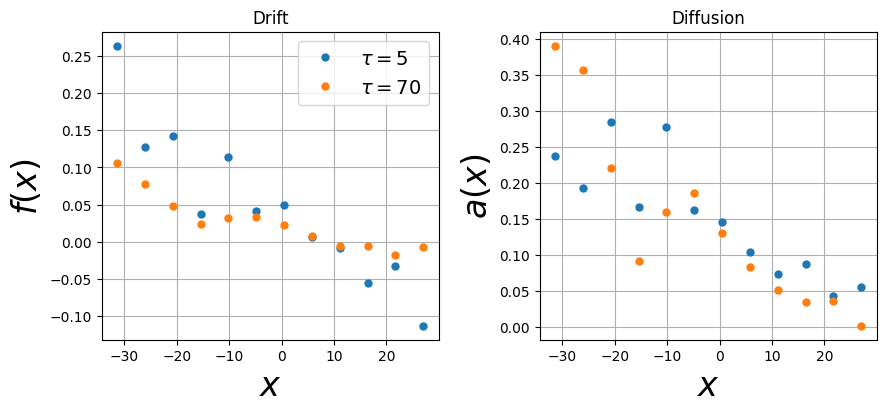

In [ ]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 16 # Number of bins
bins = np.linspace(-50,35, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t_low[i,5:,0] for i in range(num_loc)] # low flow data, pass as list into KM_avg
data_stationary = [X_t_low[i,-50:,0] for i in range(num_loc)] # for computing stationary density

f_fine, a_fine, _,_ = lg.KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=14
f_coarse, a_coarse, _,_ = lg.KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

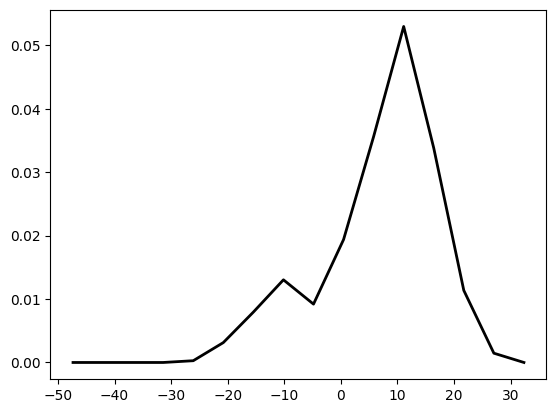

In [ ]:
# PDF of states

p_hist = np.histogram(np.concatenate(data_stationary), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

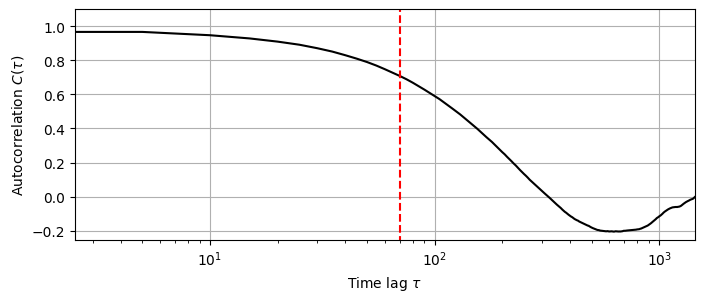

In [ ]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + tc.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/tmp/ipykernel_927/2329577854.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


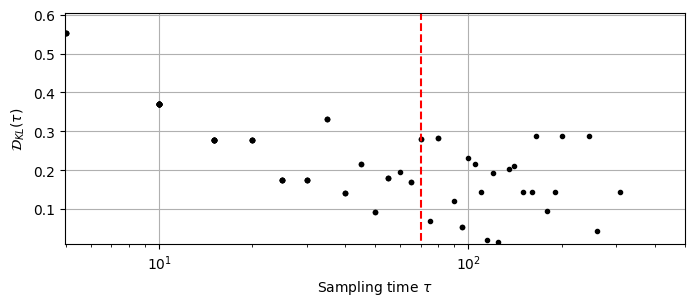

In [ ]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx], delta, N=32) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.nanmax(kl_div)+0.05])
plt.grid()

In [ ]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = lg.KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

In [ ]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_f = lib_f.T

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

lib_s = lib_s.T

In [ ]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[mask], f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[mask], np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[ 2.06602999e-02 -1.47091910e-03 -5.06432757e-05 -5.61860419e-08
  9.33608399e-08  4.70037157e-01 -6.53412238e-03 -5.90750464e-05
 -9.30767992e-06]


In [ ]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data_stationary), bins, density=True)[0]

# Initialize adjoint solver
afp = fps.AdjFP(centers)

# Initialize forward steady-state solver
fp = fps.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: lg.AFP_opt(lg.cost, params)
Xi, V = lg.SSR_loop(opt_fun, params)

%%%% Optimization time: 0.657541036605835 seconds,   Cost: 0.00021626458750719424 %%%%
[1 2 3 4]
[0 1 2 3]
[x x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 2.5264410972595215 seconds,   Cost: 0.342175228913222 %%%%
[0 2 3 4]
[0 1 2 3]
[1 x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 2.968564033508301 seconds,   Cost: 0.41269268884786664 %%%%
[0 1 3 4]
[0 1 2 3]
[1 x x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 2.7500574588775635 seconds,   Cost: 0.26953701468201446 %%%%
[0 1 2 4]
[0 1 2 3]
[1 x x**2 x**4] [1 x x**2 x**3]
%%%% Optimization time: 1.7050707340240479 seconds,   Cost: 0.00018588799901036527 %%%%
[0 1 2 3]
[0 1 2 3]
[1 x x**2 x**3] [1 x x**2 x**3]
%%%% Optimization time: 3.0283877849578857 seconds,   Cost: 0.17760856743131467 %%%%
[0 1 2 3 4]
[1 2 3]
[1 x x**2 x**3 x**4] [x x**2 x**3]
%%%% Optimization time: 2.0622501373291016 seconds,   Cost: 0.3575442023671566 %%%%
[0 1 2 3 4]
[0 2 3]
[1 x x**2 x**3 x**4] [1 x**2 x**3]
%%%% Optimization time: 2.97

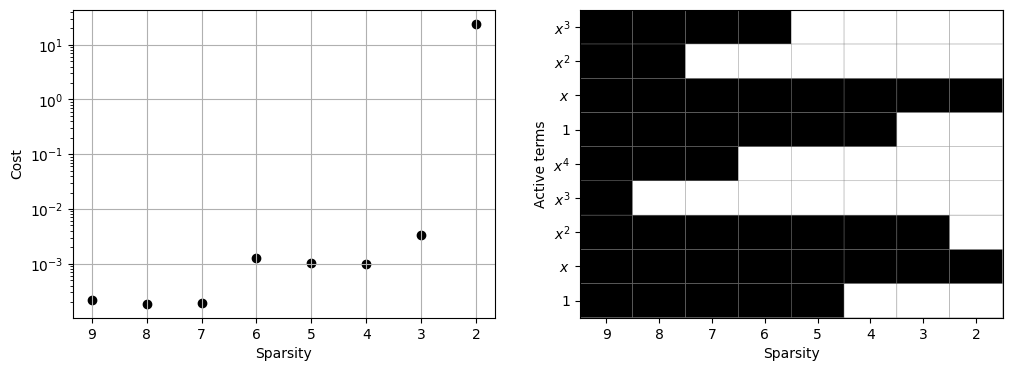

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 7
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy_low = sympy.lambdify(x, lg.sindy_model(Xi_f, f_expr))
a_sindy_low = sympy.lambdify(x, 0.5*lg.sindy_model(Xi_s, s_expr)**2)

Optimal sparsity:  7
Cost at optimal sparsity:  0.00019222966361043327
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['1.951E-02', '-1.590E-03', '-5.351E-05', '0', '1.141E-07']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['4.338E-01', '-4.346E-03', '0', '-1.231E-05']


In [ ]:
f_vals = f_sindy_low(centers)
a_vals = a_sindy_low(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

KL divergence (LINDy model): 0.20567


(-0.01, 0.07360186414874396)

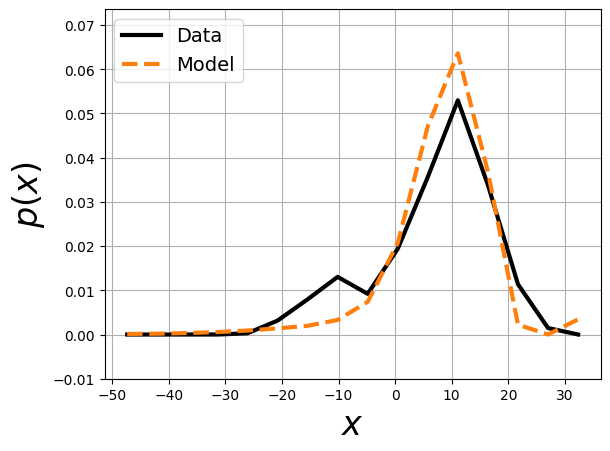

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
p_fit[p_fit<0] = 0
p_fit = p_fit/np.trapz(p_fit,centers)
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
#plt.xlim([0, 3])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()
plt.ylim([-1e-2, np.max([p_hist.max()+0.01, p_fit.max()+0.01])])

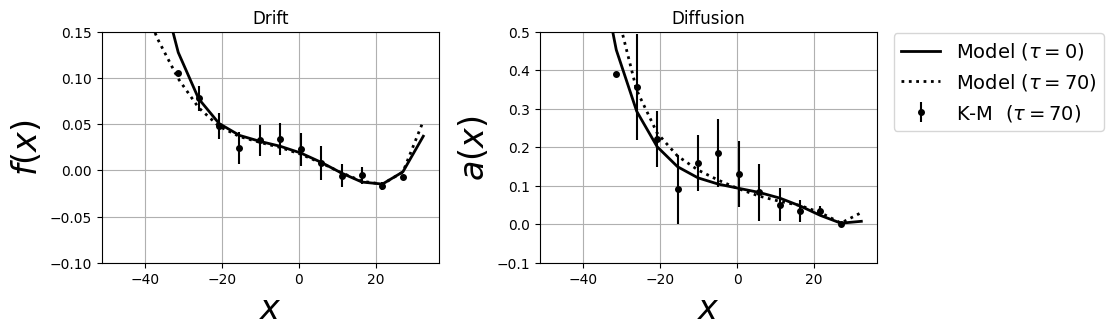

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
plt.ylim([-1e-1, 0.15])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
plt.ylim([-1e-1, 0.5])

plt.subplots_adjust(wspace=0.3)
plt.show()

/tmp/ipykernel_927/634403969.py:11: RuntimeWarning: divide by zero encountered in log
  lnP = -np.log(p_fit)


Text(0.5, 0, '$x$')

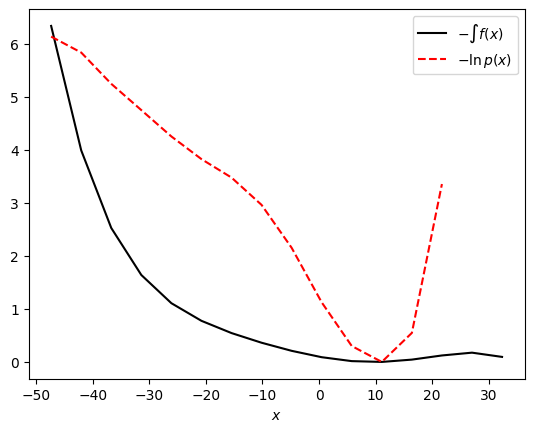

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy_low(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

lnP = -np.log(p_fit)
plt.plot(centers, Uvec-Uvec.min(), 'k-',label='$-\\int f(x)$')
plt.plot(centers, lnP-np.nanmin(lnP), 'r--',label='$-\\ln p(x)$')
plt.legend()
plt.xlabel('$x$')

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_low[inits_idx,5,0]

traj_model = stochastic_sim_EM(inits[:,None], f_sindy_low, lambda x: np.sqrt(2*a_sindy_low(x)), num_t-t_change-5, dt)[:,:,0]

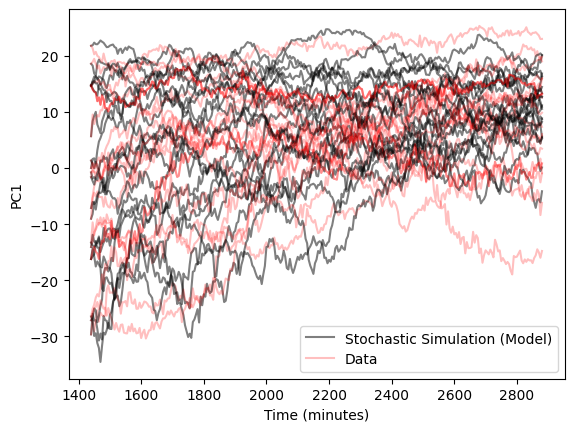

In [ ]:
for i in range(len(inits)):
    plt.plot(np.arange(t_change+5,num_t)*dt,traj_model[i,:],'k-',alpha=0.5)
    plt.plot(np.arange(t_change+5,num_t)*dt,X_t_low[inits_idx[i],5:,0],'r-',alpha=0.25)

plt.xlabel('Time (minutes)')
plt.ylabel('PC1')
plt.legend(['Stochastic Simulation (Model)','Data'])

## Langevin regression (2D)

### High flow trajectories

In [9]:
X_t_high = np.load('../data/JEPA_95pctVarPCs_highFlow.npy')

In [397]:
# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

stride = 9
dt = 5

num_loc = X_t_high.shape[0]
num_feats = X_t_high.shape[2]

data = [X_t_high[i,:,:2] for i in range(num_loc)] # high flow data, pass as list into KM_avg
data_stationary = [X_t_high[i,100:,:] for i in range(num_loc)] # "Steady state" low flow data, for histogram

Nx = 32
min0 = min([min(traj[:,0]) for traj in data])
max0 = max([max(traj[:,0]) for traj in data])
bin0_min = 0.5*(np.floor(min0)+np.round(min0,1))
bin0_max = 0.5*(np.ceil(max0)+np.round(max0,1))
bins0 = np.linspace(bin0_min, bin0_max, Nx+1)
centers0 = 0.5*(bins0[1:]+bins0[:-1])

Ny=24
min1 = min([min(traj[:,1]) for traj in data])
max1 = max([max(traj[:,1]) for traj in data])
bin1_min = 0.5*(np.floor(min1)+np.round(min1,1))
bin1_max = 0.5*(np.ceil(max1)+np.round(max1,1))
bins1 = np.linspace(bin1_min, bin1_max, Ny+1)
centers1 = 0.5*(bins1[1:]+bins1[:-1])

dx = [bins0[1]-bins0[0],bins1[1]-bins1[0]]

bins = [bins0,bins1]
centers = [centers0,centers1]

f_fine, a_fine, _,_ = lg.KM_avg_2D(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=stride
f_coarse, a_coarse, _,_ = lg.KM_avg_2D(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:109: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:110: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:111: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:112: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=-1)


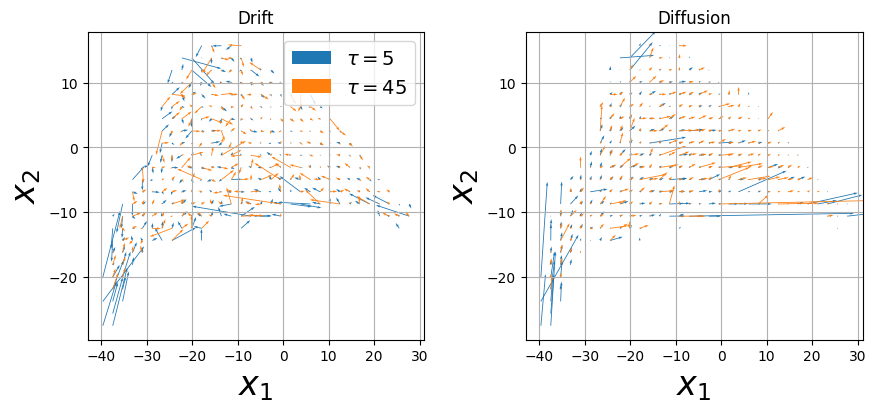

In [11]:
x1,x2 = np.meshgrid(centers0,centers1)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(x1,x2, f_fine[:,:,0].T,f_fine[:,:,1].T,color=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.quiver(x1,x2, f_coarse[:,:,0].T,f_coarse[:,:,1].T,color=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(x1,x2, a_fine[:,:,0].T,a_fine[:,:,1].T,color=colors[0])
plt.quiver(x1,x2, a_coarse[:,:,0].T, a_coarse[:,:,1].T, color=colors[1])
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

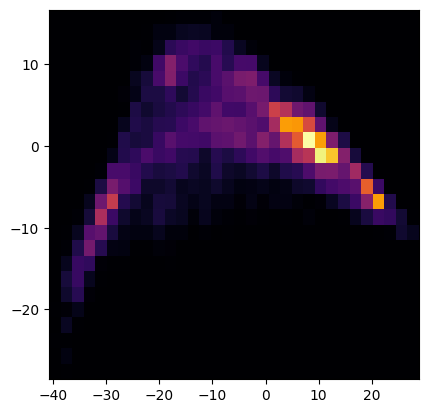

In [398]:
# PDF of states
p_hist, _, _ = np.histogram2d(np.concatenate(data_stationary)[:,0],np.concatenate(data_stationary)[:,1], bins, density=True)
plt.imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

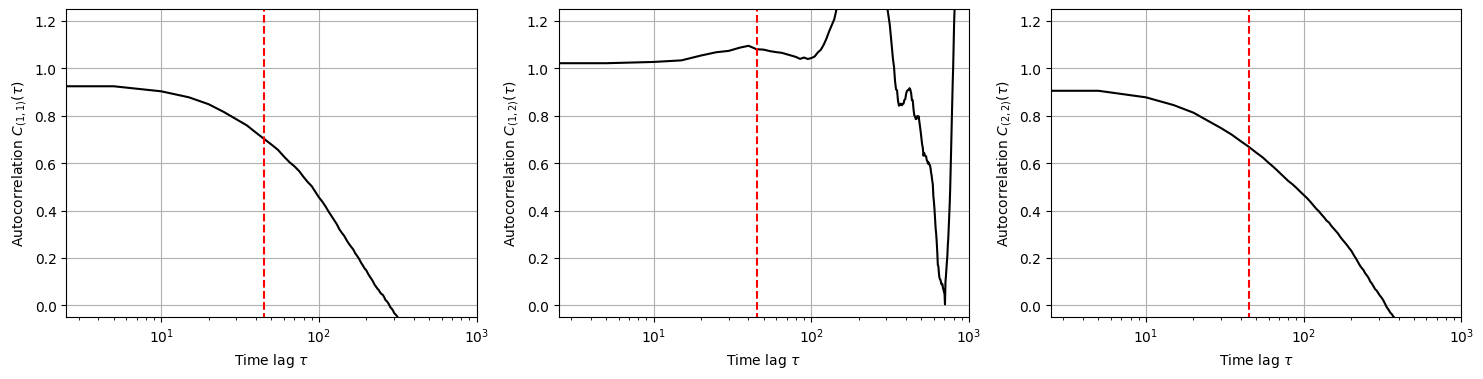

In [13]:
tau = dt*np.arange(0, data[0].shape[0])
acf = np.zeros((len(tau),2,2))
for loc_idx in range(num_loc):
    acf = acf + tc.autocorr_func_2D(data[loc_idx])
acf = acf/num_loc


fig, axs = plt.subplots(1,3, figsize=(18, 4))
tup_list = [(0,0),(0,1),(1,1)]
for ii in range(3):
    i,j = tup_list[ii]
    axs[ii].plot(tau, acf[:,i,j], 'k')
    axs[ii].set_ylabel(r'Autocorrelation $C_{('+str(i+1)+','+str(j+1)+')}(\\tau)$')
    axs[ii].set_xlabel(r'Time lag $\tau$')
    axs[ii].vlines(stride_coarse*dt, acf.min()-0.1, acf.max()+0.1, 'r', '--')
    axs[ii].set_ylim([-0.05, 1.25])
    axs[ii].set_xlim([0.5*dt, 1e3])
    axs[ii].set_xscale('log')
    axs[ii].grid()

/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_22689/3055195824.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


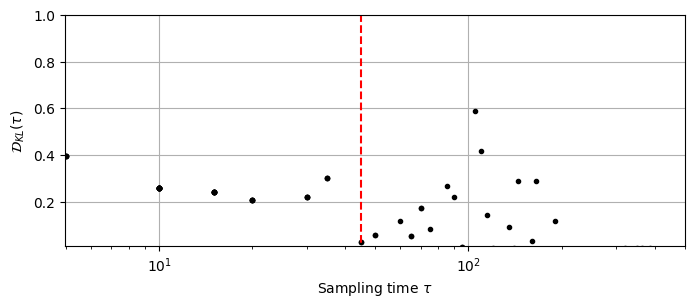

In [14]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx][:,0], delta, N=Nx) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [394]:
## Kramers-Moyal average
f_KM = np.load('../outputs/KM_drift_jepa_highFlow.npy')
a_KM = np.load('../outputs/KM_diff_jepa_highFlow.npy')
f_err = np.load('../outputs/KM_drift_err_jepa_highFlow.npy')
a_err = np.load('../outputs/KM_diff_err_jepa_highFlow.npy')

Load outputs from `langevin_2D_jepa_highFlow.py`

In [395]:
Xi_high = np.load('../outputs/coeffs_jepa_highFlow.npy')
V_high = np.load('../outputs/cost_jepa_highFlow.npy')

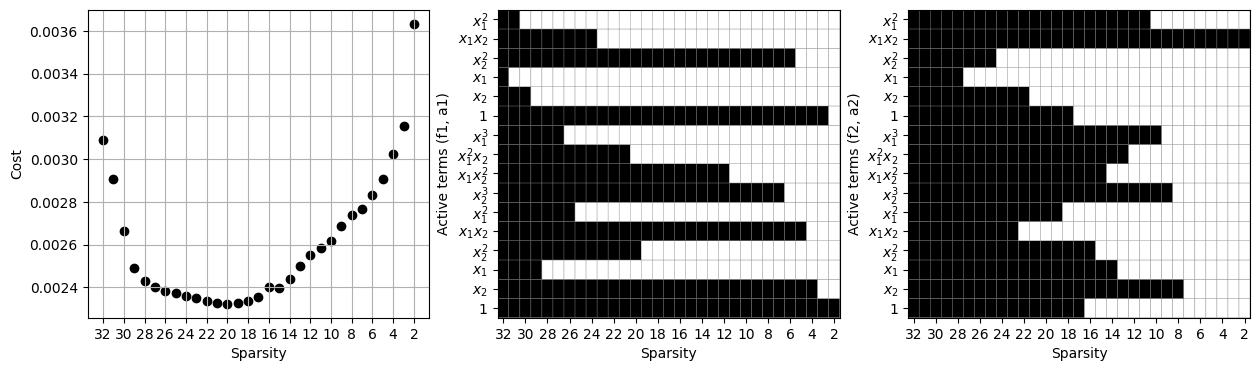

In [399]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi_high) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.scatter(np.arange(len(V_high)), V_high, c='k')

plt.gca().set_xticks(np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
#plt.gca().set_yscale('log')
plt.grid()

active_1 = np.concatenate((active[:len(f_expr)//2], active[len(f_expr):len(f_expr)+len(s_expr)//2]))
labels_1 = np.concatenate((labels[:len(f_expr)//2], labels[len(f_expr):len(f_expr)+len(s_expr)//2]))
plt.subplot(132)
plt.pcolor(active_1, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_1.shape[0]))
plt.gca().set_yticklabels(labels_1)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms (f1, a1)')


active_2 = np.concatenate((active[len(f_expr)//2:len(f_expr)], active[len(f_expr)+len(s_expr)//2:]))
labels_2 = np.concatenate((labels[len(f_expr)//2:len(f_expr)], labels[len(f_expr)+len(s_expr)//2:]))
plt.subplot(133)
plt.pcolor(active_2, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_2.shape[0]))
plt.gca().set_yticklabels(labels_2)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms (f2, a2)')

plt.show()

In [409]:
# Select model with the fewest terms before the cost function spikes
n_terms = 15
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V_high[1-n_terms])
Xi_f_high = Xi_high[:len(f_expr), 1-n_terms]
Xi_s_high = Xi_high[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr[len(f_expr)//2:])
print("SINDy expression (drift 1): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f_high[:Xi_f_high.shape[0]//2]])
print("SINDy expression (drift 2): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f_high[Xi_f_high.shape[0]//2:]])
print("Base functions (diffusion): ", s_expr[len(s_expr)//2:])
print("SINDy expression (diffusion 1): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s_high[:Xi_s_high.shape[0]//2]])
print("SINDy expression (diffusion 2): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s_high[Xi_s_high.shape[0]//2:]])

Optimal sparsity:  15
Cost at optimal sparsity:  0.0023976237049735272
Basis functions (drift):  [1 x2 x1 x2**2 x1*x2 x1**2 x2**3 x1*x2**2 x1**2*x2 x1**3]
SINDy expression (drift 1):  ['-3.090E-02', '-5.861E-03', '0', '0', '-2.894E-04', '0', '8.265E-06', '-1.286E-05', '0', '0']
SINDy expression (drift 2):  ['0', '5.276E-03', '5.938E-03', '0', '0', '0', '-9.390E-06', '-6.709E-06', '-6.268E-06', '-5.279E-06']
Base functions (diffusion):  [1 x2 x1 x2**2 x1*x2 x1**2]
SINDy expression (diffusion 1):  ['5.977E-01', '0', '0', '-5.922E-04', '0', '0']
SINDy expression (diffusion 2):  ['0', '0', '0', '0', '1.203E-03', '3.254E-04']


In [410]:
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')
f1_high = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f_high[:len(f_expr)//2]).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
f2_high = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f_high[len(f_expr)//2:]).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))

a1_high = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s_high[:len(s_expr)//2]).dot(sympy.Matrix(s_expr[:len(s_expr)//2]))**2)
a2_high = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s_high[len(s_expr)//2:]).dot(sympy.Matrix(s_expr[len(s_expr)//2:]))**2)

def f_high(X1,X2):
    return np.array([f1_high(X1,X2),f2_high(X1,X2)])

def a_high(X1,X2):
    return np.array([a1_high(X1,X2),a2_high(X1,X2)])

In [411]:
X1,X2 = np.meshgrid(centers0,centers1)
f_vals = f_high(X1,X2)
a_vals = a_high(X1,X2)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

In [412]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit = fp.solve(np.swapaxes(f_vals,1,2),np.swapaxes(a_vals,1,2))
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

KL divergence (LINDy model): 3.48531


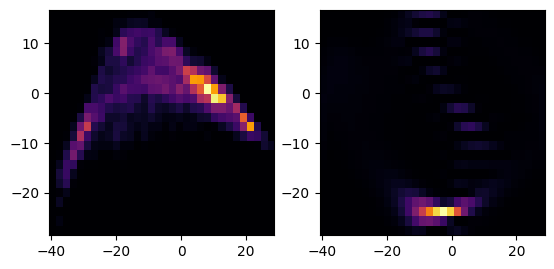

In [413]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_fit.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [414]:
afp = fps.AdjFP(centers,ndim=2)
afp.precompute_operator(f_vals.transpose((0,2,1)).reshape((2,Nx*Ny)), a_vals.transpose((0,2,1)).reshape((2,Nx*Ny)))
f_tau, a_tau = afp.solve(stride*dt,d=[0,1])

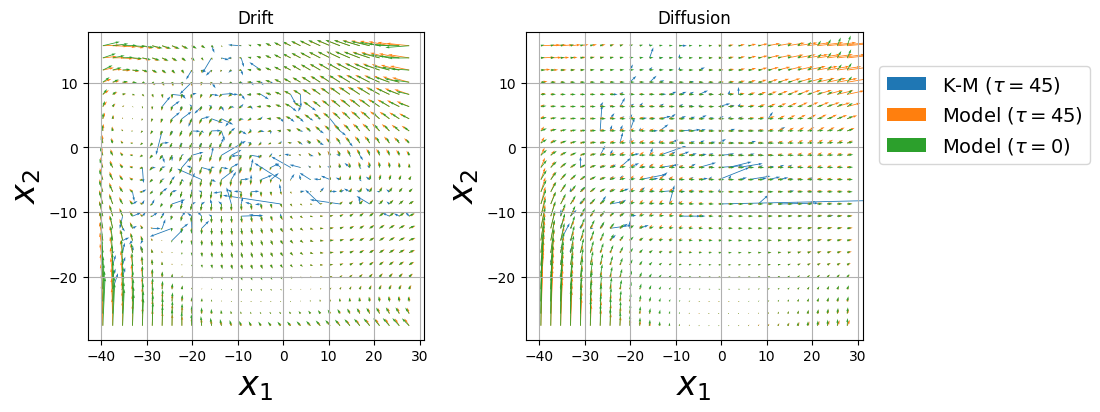

In [415]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(X1,X2, f_KM[:,:,0].T,f_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_tau[0].reshape((Nx,Ny)).T,f_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_vals[0],f_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(X1,X2, a_KM[:,:,0].T,a_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_tau[0].reshape((Nx,Ny)).T,a_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_vals[0],a_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

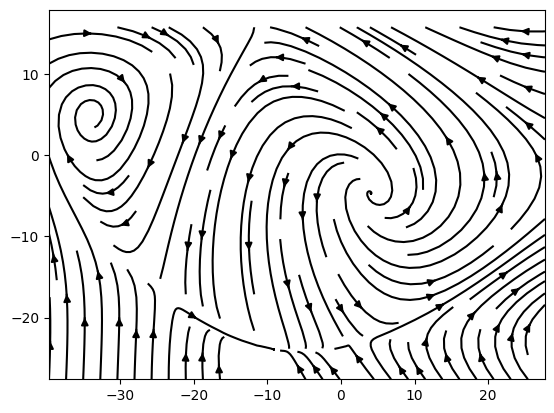

In [417]:
plt.streamplot(X1,X2,f_vals[0],f_vals[1],color='k')

Text(0, 0.5, '$x_2$')

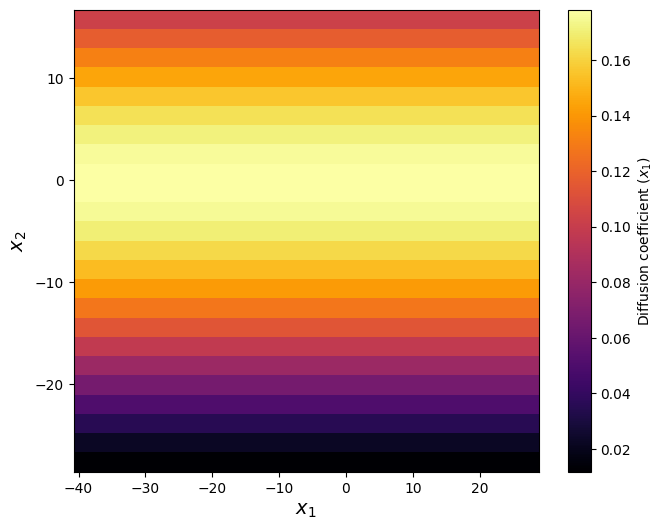

In [348]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[0],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

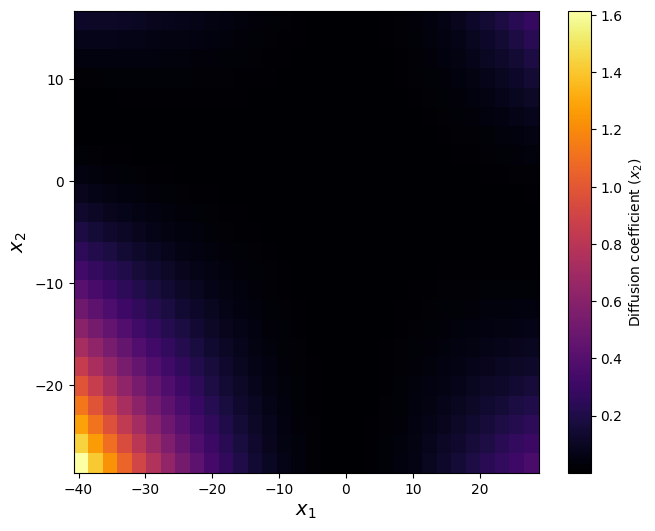

In [349]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[1],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Fixed points:
  • Saddle point at x = (-22.375,-16.091)
  • Stable node at x = (-10.852,-23.459)
  • Saddle point at x = (15.109,-22.767)


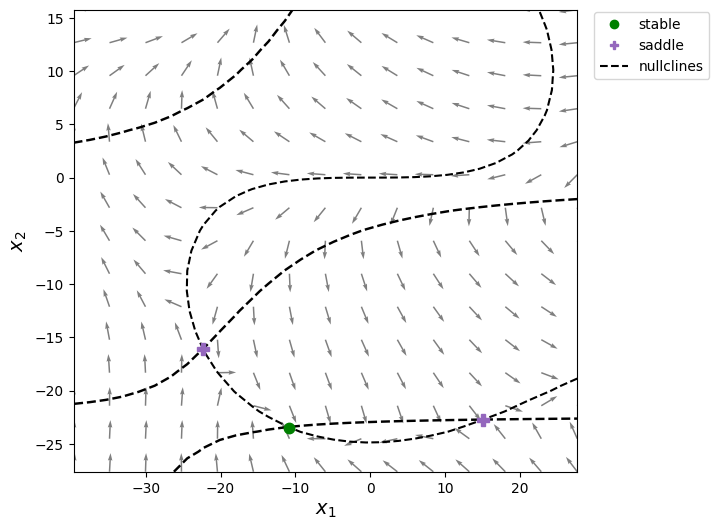

In [350]:
fig = pplane.plot_portrait(f1_high,f2_high,centers0,centers1)

In [351]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_high[inits_idx,0,:2].T

traj_model = stochastic_sim_EM(inits, lambda x: f_high(x[0],x[1]), lambda x: np.sqrt(2*a_high(x[0],x[1])), t_change, dt)

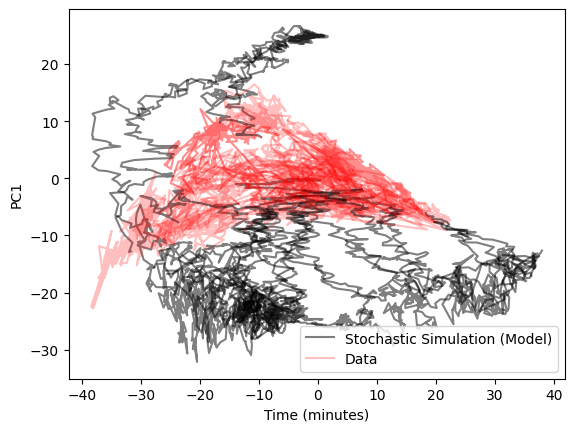

In [352]:
for i in range(len(inits_idx)):
    traj = traj_model.T[i]
    my_idx = np.where(np.linalg.norm(traj,axis=1)<40)[0]
    plt.plot(traj[my_idx,0],traj[my_idx,1],'k-',alpha=0.5)
    plt.plot(X_t_high[inits_idx[i],my_idx,0],X_t_high[inits_idx[i],my_idx,1],'r-',alpha=0.25)

#plt.ylim([-20,25])
plt.xlabel('Time (minutes)')
plt.ylabel('PC1')
plt.legend(['Stochastic Simulation (Model)','Data'])

### Low flow trajectories

In [353]:
X_t_low = np.load('../data/JEPA_95pctVarPCs_lowFlow.npy')

In [354]:
# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

stride = 9
dt = 5

num_loc = X_t_low.shape[0]
num_feats = X_t_low.shape[2]

data = [X_t_low[i,5:,:2] for i in range(num_loc)] # low flow data, pass as list into KM_avg
data_stationary = [X_t_low[i,100:,:] for i in range(num_loc)] # "Steady state" low flow data, for histogram

Nx = 32
min0 = min([min(traj[:,0]) for traj in data])
max0 = max([max(traj[:,0]) for traj in data])
bin0_min = 0.5*(np.floor(min0)+np.round(min0,1))
bin0_max = 0.5*(np.ceil(max0)+np.round(max0,1))
bins0 = np.linspace(bin0_min, bin0_max, Nx+1)
centers0 = 0.5*(bins0[1:]+bins0[:-1])

Ny=24
min1 = min([min(traj[:,1]) for traj in data])
max1 = max([max(traj[:,1]) for traj in data])
bin1_min = 0.5*(np.floor(min1)+np.round(min1,1))
bin1_max = 0.5*(np.ceil(max1)+np.round(max1,1))
bins1 = np.linspace(bin1_min, bin1_max, Ny+1)
centers1 = 0.5*(bins1[1:]+bins1[:-1])

dx = [bins0[1]-bins0[0],bins1[1]-bins1[0]]

bins = [bins0,bins1]
centers = [centers0,centers1]


f_fine, a_fine, _,_ = lg.KM_avg_2D(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=stride
f_coarse, a_coarse, _,_ = lg.KM_avg_2D(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:109: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:110: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:111: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:112: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=-1)


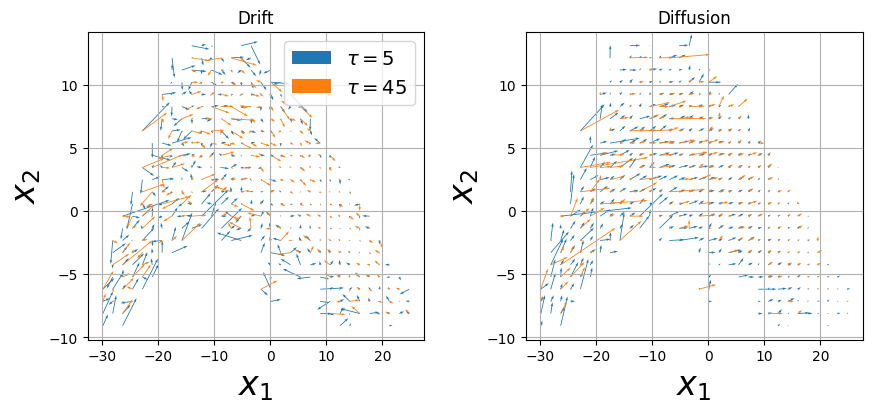

In [355]:
x1,x2 = np.meshgrid(centers0,centers1)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(x1,x2, f_fine[:,:,0].T,f_fine[:,:,1].T,color=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.quiver(x1,x2, f_coarse[:,:,0].T,f_coarse[:,:,1].T,color=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(x1,x2, a_fine[:,:,0].T,a_fine[:,:,1].T,color=colors[0])
plt.quiver(x1,x2, a_coarse[:,:,0].T, a_coarse[:,:,1].T, color=colors[1])
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

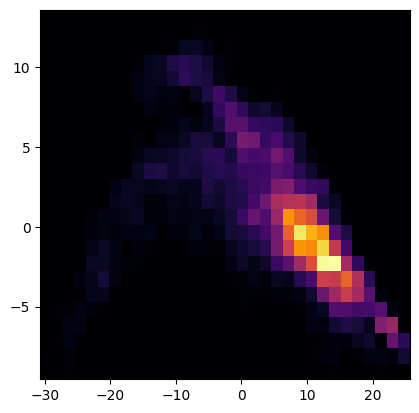

In [356]:
# PDF of states
p_hist, _, _ = np.histogram2d(np.concatenate(data_stationary)[:,0],np.concatenate(data_stationary)[:,1], bins, density=True)
plt.imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

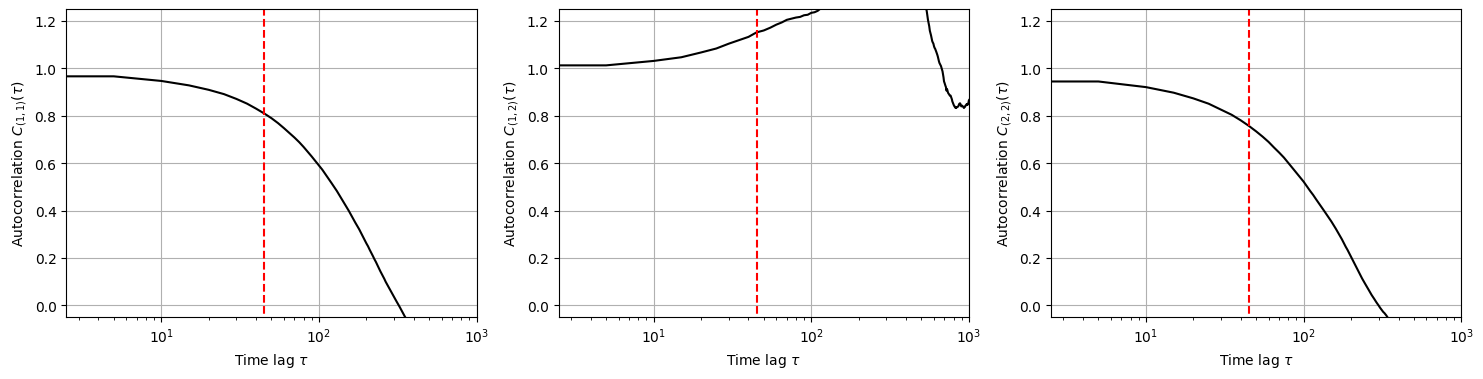

In [357]:
tau = dt*np.arange(0, data[0].shape[0])
acf = np.zeros((len(tau),2,2))
for loc_idx in range(num_loc):
    acf = acf + tc.autocorr_func_2D(data[loc_idx])
acf = acf/num_loc


fig, axs = plt.subplots(1,3, figsize=(18, 4))
tup_list = [(0,0),(0,1),(1,1)]
for ii in range(3):
    i,j = tup_list[ii]
    axs[ii].plot(tau, acf[:,i,j], 'k')
    axs[ii].set_ylabel(r'Autocorrelation $C_{('+str(i+1)+','+str(j+1)+')}(\\tau)$')
    axs[ii].set_xlabel(r'Time lag $\tau$')
    axs[ii].vlines(stride_coarse*dt, acf.min()-0.1, acf.max()+0.1, 'r', '--')
    axs[ii].set_ylim([-0.05, 1.25])
    axs[ii].set_xlim([0.5*dt, 1e3])
    axs[ii].set_xscale('log')
    axs[ii].grid()

/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_22689/3055195824.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


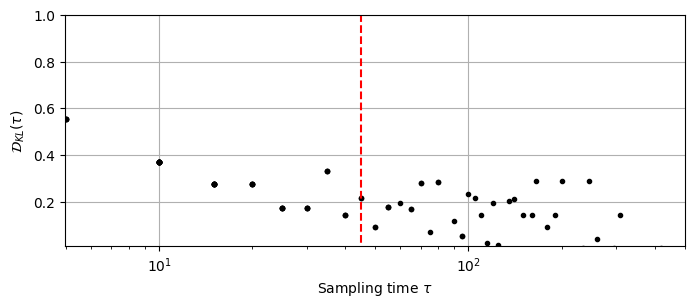

In [359]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx][:,0], delta, N=Nx) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [360]:
## Kramers-Moyal average
f_KM = np.load('../outputs/KM_drift_jepa_lowFlow.npy')
a_KM = np.load('../outputs/KM_diff_jepa_lowFlow.npy')
f_err = np.load('../outputs/KM_drift_err_jepa_lowFlow.npy')
a_err = np.load('../outputs/KM_diff_err_jepa_lowFlow.npy')

Load outputs from `langevin_2D_jepa_lowFlow.py`

In [361]:
Xi_low = np.load('../outputs/coeffs_jepa_lowFlow.npy')
V_low = np.load('../outputs/cost_jepa_lowFlow.npy')

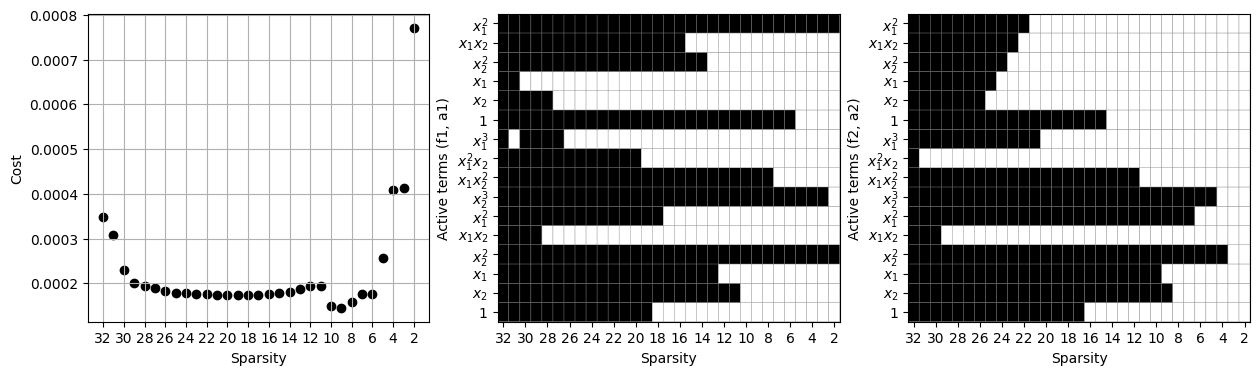

In [365]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi_low) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.scatter(np.arange(len(V_low)), V_low, c='k')

plt.gca().set_xticks(np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
#plt.gca().set_yscale('log')
plt.grid()

active_1 = np.concatenate((active[:len(f_expr)//2], active[len(f_expr):len(f_expr)+len(s_expr)//2]))
labels_1 = np.concatenate((labels[:len(f_expr)//2], labels[len(f_expr):len(f_expr)+len(s_expr)//2]))
plt.subplot(132)
plt.pcolor(active_1, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_1.shape[0]))
plt.gca().set_yticklabels(labels_1)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms (f1, a1)')


active_2 = np.concatenate((active[len(f_expr)//2:len(f_expr)], active[len(f_expr)+len(s_expr)//2:]))
labels_2 = np.concatenate((labels[len(f_expr)//2:len(f_expr)], labels[len(f_expr)+len(s_expr)//2:]))
plt.subplot(133)
plt.pcolor(active_2, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_2.shape[0]))
plt.gca().set_yticklabels(labels_2)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms (f2, a2)')

plt.show()

In [368]:
# Select model with the fewest terms before the cost function spikes
n_terms = 10
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V_low[1-n_terms])
Xi_f1_low = Xi_low[:len(f_expr)//2, 1-n_terms]
Xi_f2_low = Xi_low[len(f_expr)//2:len(f_expr), 1-n_terms]
Xi_s1_low = Xi_low[len(f_expr):len(f_expr)+len(s_expr)//2, 1-n_terms]
Xi_s2_low = Xi_low[len(f_expr)+len(s_expr)//2:, 1-n_terms]
print("Basis functions (drift): ", f_expr[:len(f_expr)//2])
print("SINDy expression (drift 1): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f1_low])
print("SINDy expression (drift 2): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f2_low])
print("Base functions (diffusion): ", s_expr[:len(s_expr)//2])
print("SINDy expression (diffusion 1): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s1_low])
print("SINDy expression (diffusion 2): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s2_low])

Optimal sparsity:  10
Cost at optimal sparsity:  0.0001492440241386699
Basis functions (drift):  [1 x2 x1 x2**2 x1*x2 x1**2 x2**3 x1*x2**2 x1**2*x2 x1**3]
SINDy expression (drift 1):  ['0', '0', '0', '2.640E-03', '0', '0', '-2.683E-04', '3.502E-05', '0', '0']
SINDy expression (drift 2):  ['0', '-4.871E-03', '-4.569E-05', '2.398E-03', '0', '-2.121E-04', '-1.567E-04', '0', '0', '0']
Base functions (diffusion):  [1 x2 x1 x2**2 x1*x2 x1**2]
SINDy expression (diffusion 1):  ['8.258E-02', '0', '0', '0', '0', '1.524E-03']
SINDy expression (diffusion 2):  ['0', '0', '0', '0', '0', '0']


In [371]:
# Functions from the expressions
# lambdify not working for some reason
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')
f1_low = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f1_low).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
f2_low = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f2_low).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))

a1_low = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s1_low).dot(sympy.Matrix(s_expr[:len(s_expr)//2]))**2)
a2_low = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s2_low).dot(sympy.Matrix(s_expr[len(s_expr)//2:]))**2)

def f_low(X1,X2):
    f1 = f1_low(X1,X2)
    f2 = f2_low(X1,X2)
    if np.isscalar(f1):
        f1 = f1 + 0*X1
    if np.isscalar(f2):
        f2 = f2 + 0*X1
    return np.array([f1,f2])

def a_low(X1,X2):
    a1 = a1_low(X1,X2)
    a2 = a2_low(X1,X2)
    if np.isscalar(a1):
        a1 = a1 + 0*X1
    if np.isscalar(a2):
        a2 = a2 + 0*X1
    return np.array([a1,a2])

In [372]:
X1,X2 = np.meshgrid(centers0,centers1)
f_vals = f_low(X1,X2)
a_vals = a_low(X1,X2)

In [373]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit = fp.solve(np.swapaxes(f_vals,1,2), np.swapaxes(a_vals,1,2))
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist.T, np.flip(p_fit.T,axis=0), dx=dx, tol=1e-6)))

KL divergence (LINDy model): 3.55266


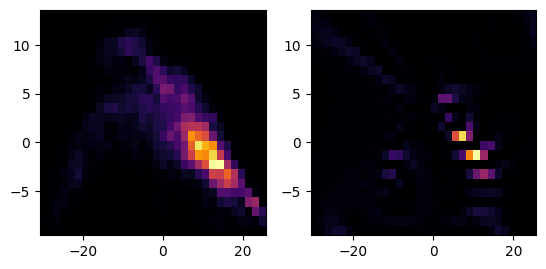

In [374]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(np.flip(p_fit.T,axis=0),interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [375]:
afp = fps.AdjFP(centers,ndim=2)
afp.precompute_operator(np.swapaxes(f_vals,1,2).reshape((2,Nx*Ny)), np.swapaxes(f_vals,1,2).reshape((2,Nx*Ny)))
f_tau, a_tau = afp.solve(stride*dt,d=[0,1])

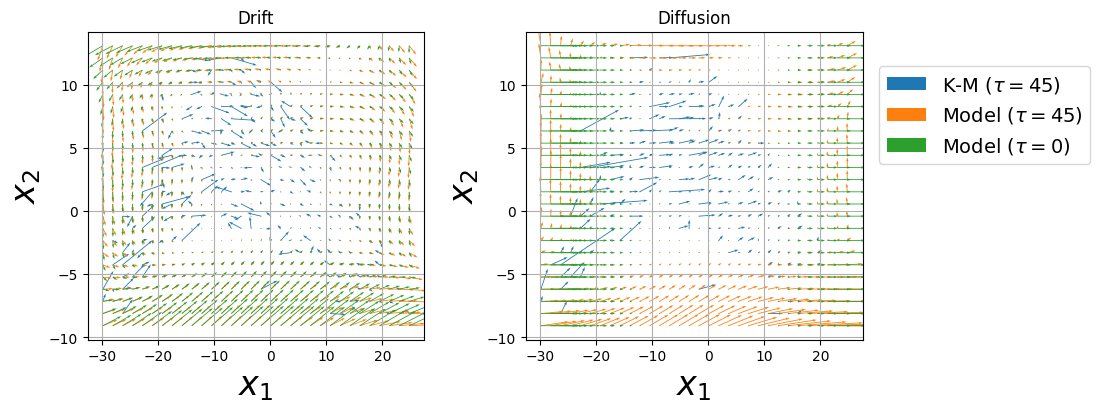

In [377]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(X1,X2, f_KM[:,:,0].T,f_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_tau[0].reshape((Nx,Ny)).T,f_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_vals[0],f_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(X1,X2, a_KM[:,:,0].T,a_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_tau[0].reshape((Nx,Ny)).T,a_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_vals[0],a_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

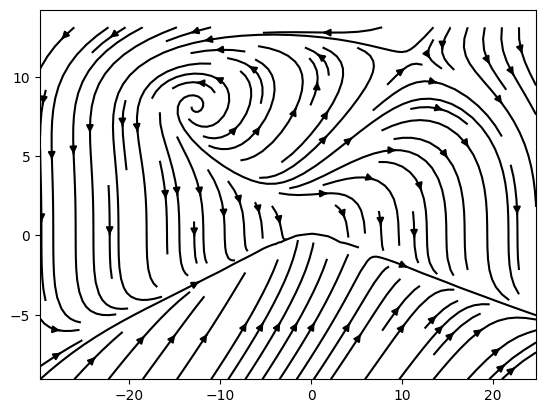

In [378]:
plt.streamplot(X1,X2,f_vals[0],f_vals[1],color='k')

Text(0, 0.5, '$x_2$')

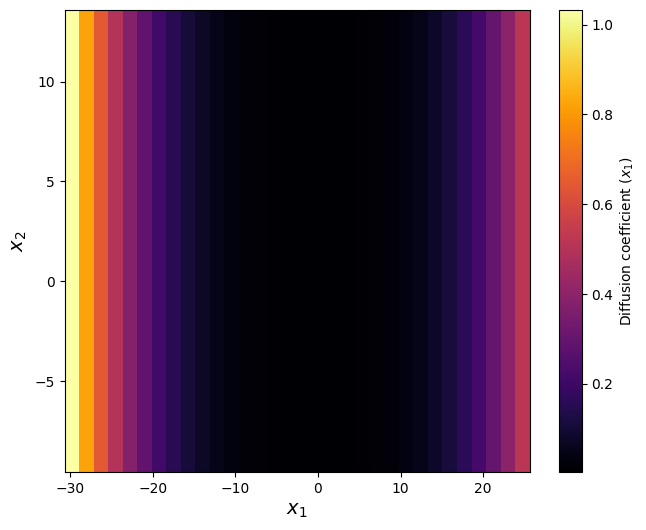

In [379]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[0],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

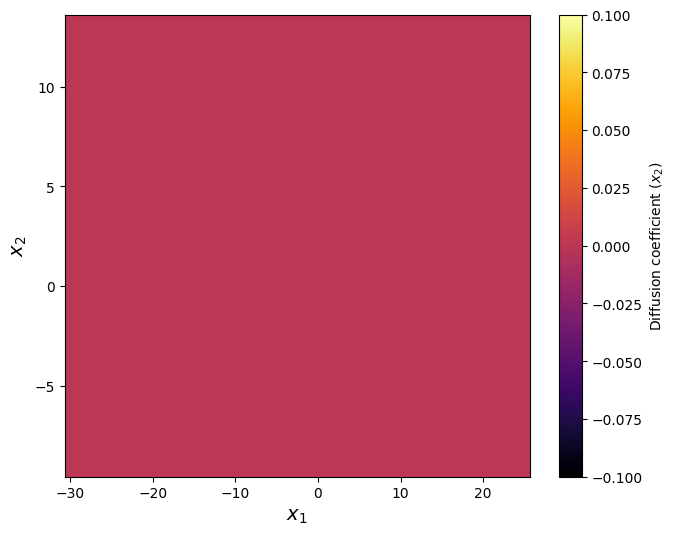

In [380]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[1],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Fixed points:
  • Stable node at x = (-0.215,0.000)
  • Saddle point at x = (10.863,11.257)
  • Unstable spiral at x = (-12.911,8.153)


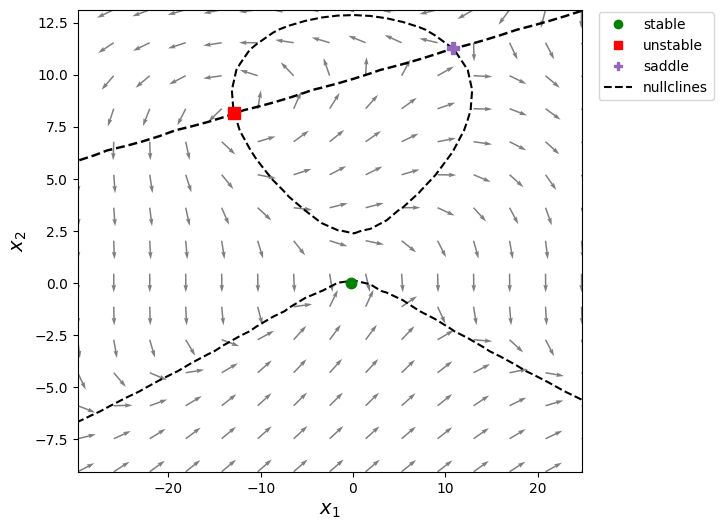

In [381]:
fig = pplane.plot_portrait(f1_low,f2_low,centers0,centers1)

In [383]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_low[inits_idx,5,:2].T

traj_model = stochastic_sim_EM(inits, lambda x: f_low(x[0],x[1]), lambda x: np.sqrt(2*a_low(x[0],x[1])), t_change, dt)

<lambdifygenerated-582151>:2: RuntimeWarning: overflow encountered in square
  return 3.50217678354947e-5*x1*x2**2 - 0.00026829571840274*x2**3 + 0.00263963219567954*x2**2
<lambdifygenerated-582151>:2: RuntimeWarning: overflow encountered in power
  return 3.50217678354947e-5*x1*x2**2 - 0.00026829571840274*x2**3 + 0.00263963219567954*x2**2
<lambdifygenerated-582151>:2: RuntimeWarning: invalid value encountered in subtract
  return 3.50217678354947e-5*x1*x2**2 - 0.00026829571840274*x2**3 + 0.00263963219567954*x2**2
<lambdifygenerated-582152>:2: RuntimeWarning: overflow encountered in square
  return -0.000212090866034422*x1**2 - 4.56926954378793e-5*x1 - 0.000156678889837834*x2**3 + 0.00239784894273763*x2**2 - 0.00487124343034969*x2
<lambdifygenerated-582152>:2: RuntimeWarning: overflow encountered in power
  return -0.000212090866034422*x1**2 - 4.56926954378793e-5*x1 - 0.000156678889837834*x2**3 + 0.00239784894273763*x2**2 - 0.00487124343034969*x2
<lambdifygenerated-582152>:2: RuntimeWar

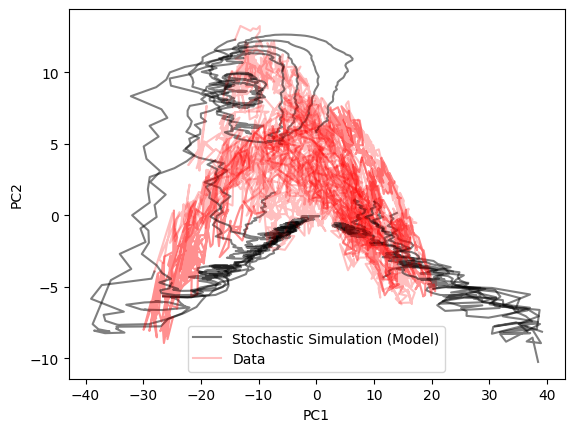

In [388]:
for i in range(len(inits_idx)):
    traj = traj_model.T[i]
    my_idx = np.where(np.linalg.norm(traj,axis=1)<40)[0]
    plt.plot(traj_model.T[i,my_idx,0],traj_model.T[i,my_idx,1],'k-',alpha=0.5)
    plt.plot(X_t_low[inits_idx[i],5:,0],X_t_low[inits_idx[i],5:,1],'r-',alpha=0.25)

#plt.ylim([-20,25])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(['Stochastic Simulation (Model)','Data'])